In [ ]:
!apt-get install tesseract-ocr
!pip install pytesseract pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [6]:
from PIL import Image
import pytesseract
from google.colab import files
uploaded = files.upload()

Saving image.png to image (1).png


In [8]:

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Open the image
img = Image.open(image_path)

# Extract text
text = pytesseract.image_to_string(img)

# Print result clearly
print("\n===== Extracted Text =====\n")
print(text)
print("\n==========================")


===== Extracted Text =====

ELLBE LIVS
Telnr. 08550 66353
org.nz .556510-7066

 

PAIN AU CHOCOLAT 4st*11,95 47,80
4 * Prisnedsattning 50,0% -23,90
‘VALLMOBROD 19,95
Klubbpris:BROD 15/sT -4,95
BAGUETTE SKAGEN 59,95
KNFS BROD 39,95

 

Totalt 7 varor
Totalt 138,80

Mottaget Kontokert 138,80
MasterCard setae 8418297
KOP 138.8 SEK
Butik:##2372

Ref: 200279162392 Term: 20027916
TvR: 0000048001 AID: A0000000041010
2026-03-05 08:34:14 ‘TSI: E800
Kontaktlés K/1 7 001 SWE 356139
Moms Moms Netto —-Brutto
12,00 14,87 123,93 138,80

 

Som klubbmedlem har du spar... 4,95
Poainggrundande belopp: 138,80
Medlemsnummer: 9752299184265782

 

SPARA KVITTOT

Man-Fre 7-21
Lér-Sén 8-21
Tack fér ditt besdk
Valkommen ater !

Du betjanades av
93305




In [9]:
# Import required libraries
import pytesseract
from PIL import Image
from google.colab import files


# Function to upload an image from the user's computer
def upload_image():
    """
    Opens a file picker so the user can upload an image.
    Returns the uploaded image file name.
    """
    print("Please upload an image for OCR processing.")
    uploaded = files.upload()

    # Get the file name of the uploaded image
    image_name = list(uploaded.keys())[0]
    return image_name


# Function to open the uploaded image
def load_image(image_path):
    """
    Opens the image using Pillow.
    """
    img = Image.open(image_path)
    return img


# Function to extract text using Tesseract OCR
def extract_text(image):
    """
    Uses pytesseract to convert image text into a string.
    """
    text = pytesseract.image_to_string(image)
    return text


# Function to display the OCR results clearly
def display_text(text):
    """
    Prints the extracted text with clear labels.
    """
    print("\n========== OCR RESULT ==========\n")

    if text.strip() == "":
        print("No text detected in the image.")
    else:
        print(text)

    print("\n================================")


# Main function to run the full OCR process
def main():
    """
    Controls the complete OCR workflow.
    """

    # Step 1: Upload image
    image_path = upload_image()

    # Step 2: Load image
    image = load_image(image_path)

    # Step 3: Extract text
    extracted_text = extract_text(image)

    # Step 4: Display results
    display_text(extracted_text)


# Run the program
main()

Please upload an image for OCR processing.


Saving image.png to image (2).png

========== OCR RESULT ==========

ELLBE LIVS
Telnr. 08550 66353
org.nz .556510-7066

 

PAIN AU CHOCOLAT 4st*11,95 47,80
4 * Prisnedsattning 50,0% -23,90
‘VALLMOBROD 19,95
Klubbpris:BROD 15/sT -4,95
BAGUETTE SKAGEN 59,95
KNFS BROD 39,95

 

Totalt 7 varor
Totalt 138,80

Mottaget Kontokert 138,80
MasterCard setae 8418297
KOP 138.8 SEK
Butik:##2372

Ref: 200279162392 Term: 20027916
TvR: 0000048001 AID: A0000000041010
2026-03-05 08:34:14 ‘TSI: E800
Kontaktlés K/1 7 001 SWE 356139
Moms Moms Netto —-Brutto
12,00 14,87 123,93 138,80

 

Som klubbmedlem har du spar... 4,95
Poainggrundande belopp: 138,80
Medlemsnummer: 9752299184265782

 

SPARA KVITTOT

Man-Fre 7-21
Lér-Sén 8-21
Tack fér ditt besdk
Valkommen ater !

Du betjanades av
93305




**OCR Real World Test**

**Clear image** won easily — printed text on white background, Tesseract nailed it with maybe one or two tiny punctuation mistakes.

**Difficult image** was a mess — handwriting and angled/blurry photos gave back garbled symbols, missing words, sometimes pure nonsense.

**Why?** OCR is basically pattern matching. Clean contrast + standard fonts = easy. Shadows, weird angles, handwriting = it falls apart fast because Tesseract was never really trained for that kind of chaos.

In [10]:
import pytesseract
from PIL import Image
from google.colab import files
import cv2
import numpy as np
import re

# Function to upload an image
def upload_image():
    print("Please upload an image for OCR processing.")
    uploaded = files.upload()
    image_name = list(uploaded.keys())[0]
    return image_name

# Function to load the image
def load_image(image_path):
    img = cv2.imread(image_path)
    return img

# Function to preprocess the image
def preprocess_image(img):
    """
    Steps:
    1. Convert to grayscale
    2. Apply thresholding to remove background
    3. Optional: remove noise using morphological operations
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply adaptive thresholding for varying lighting conditions
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    # Remove small noise using morphological opening
    kernel = np.ones((1,1), np.uint8)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # Convert back to PIL Image for pytesseract
    processed_img = Image.fromarray(clean)
    return processed_img

# Function to perform OCR
def extract_text(image):
    text = pytesseract.image_to_string(image)
    return text

# Function to clean OCR text
def clean_text(text):
    """
    Removes unnecessary characters and extra whitespace
    """
    # Remove non-printable characters
    text = re.sub(r'[^\x20-\x7E\n]', '', text)

    # Replace multiple spaces/newlines with single ones
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r' +', ' ', text)

    # Strip leading/trailing spaces
    text = text.strip()

    return text

# Function to display results clearly
def display_text(text):
    print("\n========== OCR RESULT ==========\n")
    if text == "":
        print("No text detected or image too poor for OCR.")
    else:
        print(text)
    print("\n================================")

# Main function to run the OCR workflow
def main():
    image_path = upload_image()
    img = load_image(image_path)
    processed_img = preprocess_image(img)
    extracted_text = extract_text(processed_img)
    cleaned_text = clean_text(extracted_text)
    display_text(cleaned_text)

# Run the OCR program
main()

Please upload an image for OCR processing.


Saving image.png to image (3).png

========== OCR RESULT ==========

ELLBE LIvs
Telnr, 08550 66353
org nr, 556510-7066
 
PAIN AU CHOCOLAT asteii,95 47,20
4 * Prisnedsattning 50,0% -23,90
VALLMOBRED 19,95
Xlubbpris:BRp 15/sT 74,95
BAGUETTE SKAGEN 59,95
ENFS BRED 39,95
 
Totalt 7 varor
Totalt 138,80 SEK
Mottaget Kontokert: 138,20
MasterCard Prereerere eerie
KOP 138.8 SEK
Butik:*42372
Ref: 200279162392 Term: 20027916
wR: coodosa001 Ap: aggodoodos1010
2026-03-05 08:34:14 TSI: Ea00
Kontaktls K/1 7 001 SWE 356139
Moms Moms Netto -Brutto
12,00 14,87 123,93 138,20
 
 
Som Klubbmediem har du spar,, 4,95
Podnggrundande belopp: 138,20
MedLemsnunme: 9752299184265782
 
 
SPARA KVITTOT
Min-Fre 7-21
Lr-Sn 8-21
Tack fx ditt besk
Valkommen
 
Du betjanades av
93305



**Real-world OCR use case: Invoice Processing**

**Input:** A scanned or photographed paper invoice from a supplier.

**Output:** Extracted text — vendor name, date, items, total amount — saved directly into a spreadsheet or accounting software.

**Why OCR?** Because manually typing hundreds of invoices is slow and error-prone. OCR reads the document in seconds and pulls the data automatically. No human typing needed.

Simple as that — OCR turns a pile of paper into usable data.

**Is OCR enough? No.**

OCR just converts what it *sees* into text. It has no idea what that text *means*.

It doesn't know "due date" means you owe money soon, or that a number in a table is a price vs. a phone number. It just dumps raw text at you.

To actually *understand* a document you need more — NLP to catch meaning, NER to spot names/dates/amounts, and honestly something like an LLM to reason through the whole thing properly.

OCR is like eyes we would still need thinking aspect(brain).

Upload an image for OCR highlighting:


Saving image.png to image (4).png


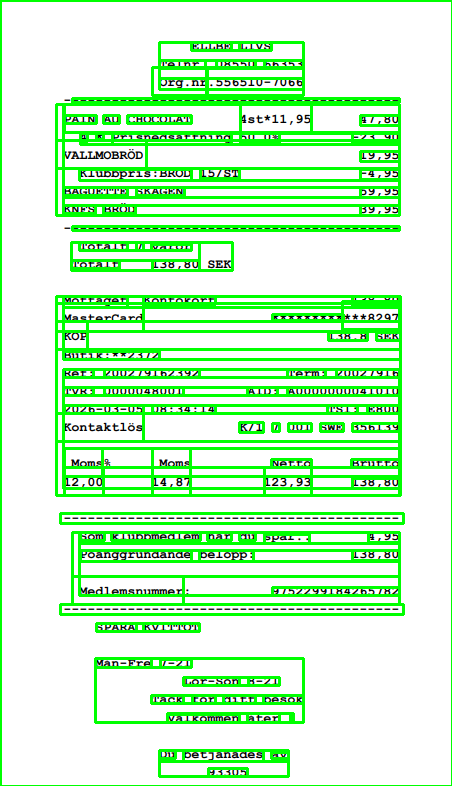


========== OCR Result ==========

 

 

 

 

 




In [11]:
import pytesseract
from PIL import Image
from google.colab import files
import cv2

# Upload image
def upload_image():
    print("Upload an image for OCR highlighting:")
    uploaded = files.upload()
    return list(uploaded.keys())[0]

# Load image with OpenCV
def load_image(image_path):
    img = cv2.imread(image_path)
    return img

# Draw rectangles around detected text
def highlight_text(img):
    """
    Uses pytesseract to get bounding boxes of text and draws rectangles.
    """
    # Convert image to RGB (required for pytesseract image_to_data)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get bounding boxes
    data = pytesseract.image_to_data(rgb, output_type=pytesseract.Output.DICT)

    n_boxes = len(data['level'])
    for i in range(n_boxes):
        (x, y, w, h) = (data['left'][i], data['top'][i], data['width'][i], data['height'][i])
        # Draw rectangle around text
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return img

# Main workflow
def main():
    image_path = upload_image()
    img = load_image(image_path)

    # Highlight text
    highlighted_img = highlight_text(img)

    # Convert to RGB for display in Colab
    highlighted_img_rgb = cv2.cvtColor(highlighted_img, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(highlighted_img_rgb))

    # Extract text as before
    text = pytesseract.image_to_string(highlighted_img_rgb)
    print("\n========== OCR Result ==========\n")
    print(text)
    print("\n================================")

# Run program
main()